## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes.
* Este notebook está resuelto **paso a paso y explicado de forma sencilla**, como si fuera la primera vez que trabajamos con una red convolucional. Cada bloque de código va precedido de una explicación de *qué* vamos a hacer y *por qué*.


### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Fijamos una semilla para que los resultados sean lo más reproducibles posible
np.random.seed(42)
tf.random.set_seed(42)


### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear: hay muchos sistemas de detección automática de imágenes capaces de distinguir perros de gatos y saltarse el CAPTCHA. Por eso nos han pedido entrenar un modelo potente de clasificación que emule a esos sistemas "malos", con el objetivo de quedarnos con las fotos que ese modelo peor clasifica (las más "difíciles") para usarlas en el CAPTCHA.

Tenemos:
- **Train**: 4000 imágenes de perros y gatos repartidas en 4 carpetas (`github_train_0`, `github_train_1`, `github_train_2`, `github_train_3`).
- **Test**: 1000 imágenes en la carpeta `github_test`, que es de donde tenemos que sacar las imágenes "más difíciles".

La clase de cada imagen (perro o gato) está en el **nombre del archivo** (por ejemplo `cat.1000.jpg` o `dog.234.jpg`), así que la sacaremos de ahí.


## 1. Crear los datasets X, y de train y test

Vamos a escribir una función sencilla que:

1. Recorre una lista de carpetas.
2. Lee cada imagen con `cv2.imread`.
3. La convierte de BGR a RGB (OpenCV lee las imágenes en un orden de colores distinto al habitual, hay que "arreglarlo" para que se vean bien).
4. La redimensiona a 32x32 píxeles (así todas las imágenes tienen el mismo tamaño, algo imprescindible para meterlas en una red neuronal).
5. Mira el nombre del archivo: si empieza por `cat` la etiqueta es 0 (gato), si empieza por `dog` la etiqueta es 1 (perro).

Al final tendremos un array `X` con todas las imágenes (en forma de números) y un array `y` con las etiquetas (0 o 1).


In [2]:
DATA_DIR = "data"
TRAIN_DIRS = ["github_train_0", "github_train_1", "github_train_2", "github_train_3"]
TEST_DIR = "github_test"
IMG_SIZE = 32  # todas las imagenes se van a quedar en 32x32 pixeles


def cargar_imagenes(directorios):
    """
    Recorre una lista de carpetas dentro de DATA_DIR, lee todas las imagenes .jpg,
    las redimensiona a IMG_SIZE x IMG_SIZE y saca la clase (gato=0, perro=1) del nombre del archivo.
    Devuelve dos arrays de numpy: X (imagenes) e y (etiquetas)
    """
    X = []
    y = []
    for carpeta in directorios:
        ruta_carpeta = os.path.join(DATA_DIR, carpeta)
        for nombre_archivo in sorted(os.listdir(ruta_carpeta)):
            if not nombre_archivo.lower().endswith(".jpg"):
                continue

            ruta_imagen = os.path.join(ruta_carpeta, nombre_archivo)

            imagen = cv2.imread(ruta_imagen)
            imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
            imagen = cv2.resize(imagen, (IMG_SIZE, IMG_SIZE))

            X.append(imagen)

            # la clase esta en el nombre del archivo: "cat.123.jpg" o "dog.123.jpg"
            etiqueta = 0 if nombre_archivo.startswith("cat") else 1
            y.append(etiqueta)

    return np.array(X), np.array(y)


Ahora cargamos las imágenes de entrenamiento (las 4 carpetas de train) y las de test (`github_test`). Puede tardar unos segundos, ya que son 5000 imágenes en total.

In [3]:
X_train, y_train = cargar_imagenes(TRAIN_DIRS)
X_test, y_test = cargar_imagenes([TEST_DIR])

print("Forma de X_train:", X_train.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de y_test:", y_test.shape)


Forma de X_train: (4000, 32, 32, 3)
Forma de y_train: (4000,)
Forma de X_test: (1000, 32, 32, 3)
Forma de y_test: (1000,)


`X_train.shape` nos dice: `(4000, 32, 32, 3)`. Eso significa: 4000 imágenes, cada una de 32x32 píxeles y 3 canales de color (Rojo, Verde, Azul).

Antes de meter las imágenes en la red, las **normalizamos**: dividimos todos los valores de píxel (que van de 0 a 255) entre 255, para que queden entre 0 y 1. Las redes neuronales aprenden mejor y más rápido con números pequeños.


In [4]:
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

print("Valor minimo y maximo de X_train_norm:", X_train_norm.min(), X_train_norm.max())


Valor minimo y maximo de X_train_norm: 0.0 1.0


## 2. MiniEDA y visualización del dataset

Antes de construir el modelo, vamos a echar un vistazo rápido a los datos:

1. ¿Cuántas imágenes hay de cada clase? (queremos que esté equilibrado, si no el modelo se puede "vaguear" prediciendo siempre la clase mayoritaria)
2. ¿Qué pinta tienen las imágenes?


gato     2000
perro    2000
Name: count, dtype: int64


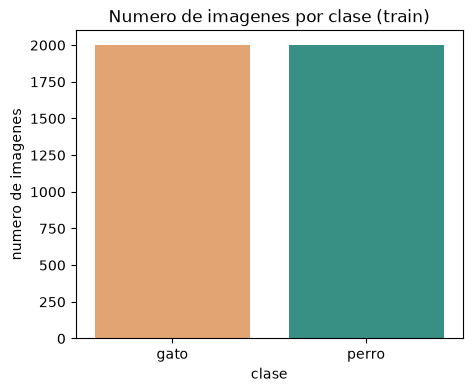

In [5]:
import pandas as pd

conteo = pd.Series(y_train).map({0: "gato", 1: "perro"}).value_counts()
print(conteo)

plt.figure(figsize=(5, 4))
sns.barplot(x=conteo.index, y=conteo.values, hue=conteo.index, palette=["#f4a261", "#2a9d8f"], legend=False)
plt.title("Numero de imagenes por clase (train)")
plt.ylabel("numero de imagenes")
plt.xlabel("clase")
plt.show()


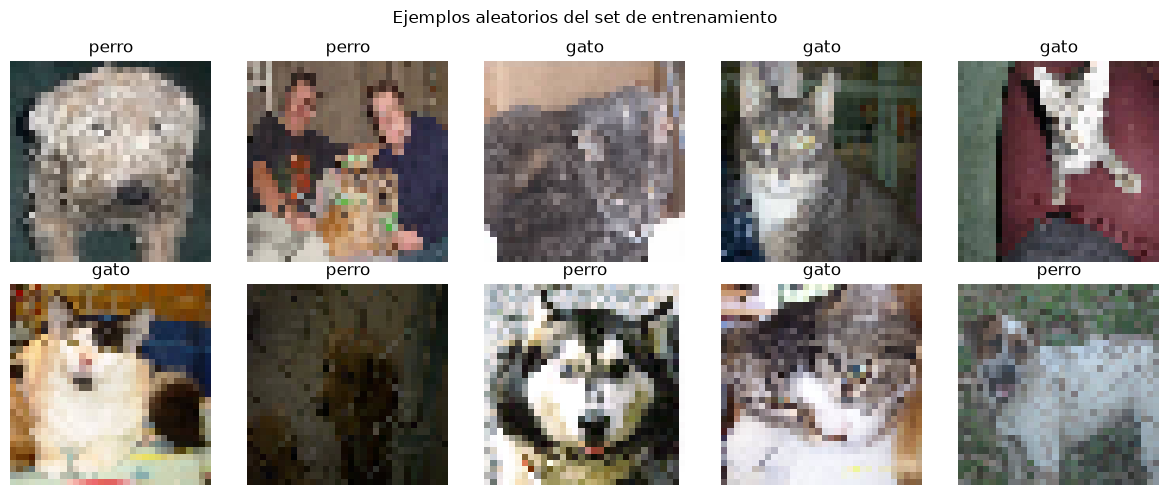

In [6]:
clases = {0: "gato", 1: "perro"}

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax in axes.flatten():
    idx = np.random.randint(0, len(X_train))
    ax.imshow(X_train[idx])
    ax.set_title(clases[y_train[idx]])
    ax.axis("off")

plt.suptitle("Ejemplos aleatorios del set de entrenamiento")
plt.tight_layout()
plt.show()


Las imágenes en 32x32 se ven un poco pixeladas (es normal, hemos reducido mucho su tamaño para que el entrenamiento sea rápido), pero aún así se distingue bastante bien si es un perro o un gato.

## 3. Construcción del modelo (red convolucional)

Vamos a crear una red convolucional sencilla con **dos bloques Convolucional + Pooling**, tal y como pide el enunciado:

- **Conv2D**: aplica "filtros" que aprenden a detectar patrones en la imagen (bordes, texturas, formas...). Cuantos más filtros, más patrones distintos puede aprender a reconocer.
- **MaxPooling2D**: reduce el tamaño de la imagen quedándose con el valor más alto de cada región. Esto hace la red más rápida y ayuda a que se fije en lo importante, no en el detalle exacto de cada píxel.
- **Flatten**: convierte la imagen (que a estas alturas es una especie de "mapa de características" en 3D) en un vector plano, para poder conectarlo a capas normales (Dense).
- **Dense**: capas "clásicas" de una red neuronal, donde cada neurona se conecta con todas las de la capa anterior.
- **Dropout**: apaga aleatoriamente algunas neuronas durante el entrenamiento, para evitar que el modelo se "aprenda de memoria" los datos de entrenamiento (overfitting).
- Como es un problema de **clasificación binaria** (gato vs perro), la última capa tiene 1 neurona con activación `sigmoid`, que nos da un número entre 0 y 1 (la probabilidad de que sea un perro).


In [7]:
model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # primer bloque convolucional
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    # segundo bloque convolucional
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 281,665 (1.07 MB)

 Trainable params: 281,665 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Entrenamiento con EarlyStopping

Para entrenar, separamos una parte del propio train como **validación** (`validation_split=0.2`, un 20%), para poder vigilar cómo se comporta el modelo con datos que no está usando para aprender.

Usamos el callback `EarlyStopping`: si la pérdida de validación (`val_loss`) deja de mejorar durante varias épocas seguidas (la "paciencia", aquí ponemos 4), el entrenamiento se para solo y nos quedamos con los mejores pesos (`restore_best_weights=True`). Así evitamos entrenar de más y que el modelo empiece a sobreajustar (overfitting).


In [8]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
)

history = model.fit(
    X_train_norm, y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=2,
)


Epoch 1/25
100/100 - 5s - 54ms/step - accuracy: 0.6219 - loss: 0.6648 - val_accuracy: 0.0000e+00 - val_loss: 0.8420
Epoch 2/25
100/100 - 3s - 26ms/step - accuracy: 0.6494 - loss: 0.6263 - val_accuracy: 0.7725 - val_loss: 0.6120
Epoch 3/25
100/100 - 3s - 28ms/step - accuracy: 0.6906 - loss: 0.5845 - val_accuracy: 0.7425 - val_loss: 0.5883
Epoch 4/25
100/100 - 3s - 26ms/step - accuracy: 0.7188 - loss: 0.5468 - val_accuracy: 0.7638 - val_loss: 0.5404
Epoch 5/25
100/100 - 3s - 28ms/step - accuracy: 0.7434 - loss: 0.5196 - val_accuracy: 0.7500 - val_loss: 0.5477
Epoch 6/25
100/100 - 3s - 26ms/step - accuracy: 0.7656 - loss: 0.4878 - val_accuracy: 0.7887 - val_loss: 0.4794
Epoch 7/25
100/100 - 3s - 26ms/step - accuracy: 0.7881 - loss: 0.4459 - val_accuracy: 0.7400 - val_loss: 0.5364
Epoch 8/25
100/100 - 3s - 26ms/step - accuracy: 0.8072 - loss: 0.4109 - val_accuracy: 0.6913 - val_loss: 0.6198
Epoch 9/25
100/100 - 3s - 26ms/step - accuracy: 0.8325 - loss: 0.3740 - val_accuracy: 0.6837 - val_l

Vamos a pintar cómo ha evolucionado el `accuracy` (precisión) y el `loss` (error) durante el entrenamiento, tanto en train como en validación.

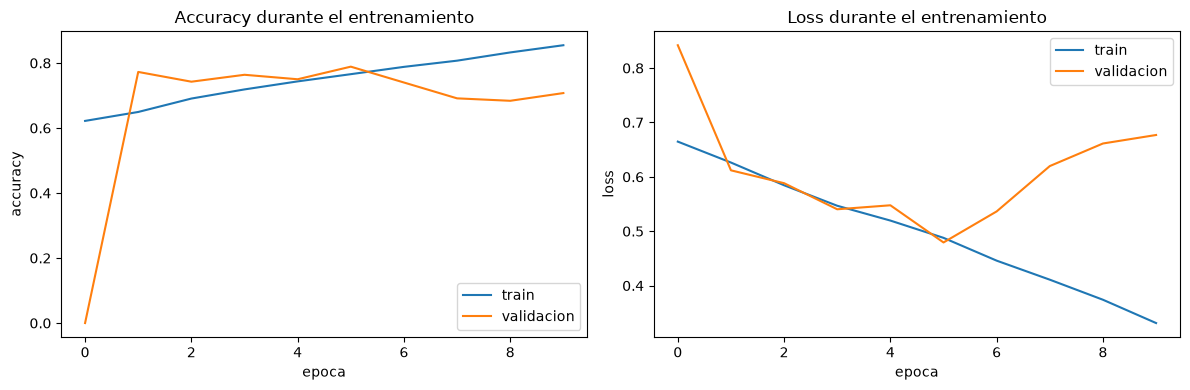

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="validacion")
axes[0].set_title("Accuracy durante el entrenamiento")
axes[0].set_xlabel("epoca")
axes[0].set_ylabel("accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="validacion")
axes[1].set_title("Loss durante el entrenamiento")
axes[1].set_xlabel("epoca")
axes[1].set_ylabel("loss")
axes[1].legend()

plt.tight_layout()
plt.show()


## 5. Evaluación del modelo

Ahora usamos el modelo ya entrenado para predecir sobre el set de **test** (imágenes que el modelo no ha visto nunca). Como la última capa es una `sigmoid`, la predicción es un número entre 0 y 1 que interpretamos como "probabilidad de que sea un perro". Si es mayor o igual a 0.5, decimos que el modelo predice "perro"; si no, "gato".


In [10]:
y_prob = model.predict(X_test_norm, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=["gato", "perro"]))


              precision    recall  f1-score   support

        gato       0.76      0.62      0.68       500
       perro       0.68      0.80      0.73       500

    accuracy                           0.71      1000
   macro avg       0.72      0.71      0.71      1000
weighted avg       0.72      0.71      0.71      1000



La **matriz de confusión** nos permite ver, de un vistazo, en qué se equivoca el modelo: cuántos gatos ha confundido con perros y viceversa.

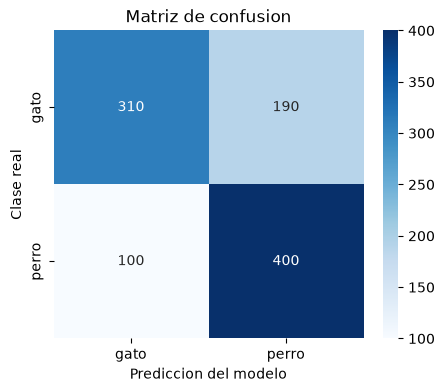

In [11]:
matriz = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues",
            xticklabels=["gato", "perro"], yticklabels=["gato", "perro"])
plt.xlabel("Prediccion del modelo")
plt.ylabel("Clase real")
plt.title("Matriz de confusion")
plt.show()


## 6. Seleccionar las imágenes más "difíciles"

Ahora viene la parte que nos pedía la empresa: quedarnos con las imágenes que el modelo clasifica **peor**, es decir:

- Las que están **mal clasificadas** (el modelo se equivoca de clase).
- Y dentro de esas, las que tienen **mayor confianza en el error** (por ejemplo, un perro que el modelo dice que es gato con un 95% de seguridad, es un caso "más difícil" que uno con un 51%).
- Nos quedamos con el **10%** de esas imágenes mal clasificadas (del total de errores, no del total del test), tanto para la clase gato como para la clase perro.

Para medir la "confianza en el error" usamos `y_prob`: si el modelo predijo "perro" (1) pero era gato, la confianza del error es `y_prob` (cuanto más cerca de 1, más convencido estaba de que era perro). Si predijo "gato" (0) pero era perro, la confianza del error es `1 - y_prob`.


In [12]:
# indices de las imagenes mal clasificadas
mal_clasificadas_idx = np.where(y_pred != y_test)[0]
print("Numero de imagenes mal clasificadas:", len(mal_clasificadas_idx))

# "confianza en el error": si predijo perro (1), usamos la probabilidad tal cual;
# si predijo gato (0), usamos 1 - probabilidad (para saber lo seguro que estaba de esa prediccion)
confianza_error = np.where(
    y_pred[mal_clasificadas_idx] == 1,
    y_prob[mal_clasificadas_idx],
    1 - y_prob[mal_clasificadas_idx],
)

# ordenamos de mayor a menor confianza en el error
orden = mal_clasificadas_idx[np.argsort(-confianza_error)]

# nos quedamos con el 10% de las imagenes mal clasificadas
n_seleccion = max(1, int(0.10 * len(mal_clasificadas_idx)))
imagenes_dificiles_idx = orden[:n_seleccion]

print(f"Nos quedamos con {n_seleccion} imagenes (el 10% de las mal clasificadas)")


Numero de imagenes mal clasificadas: 290
Nos quedamos con 29 imagenes (el 10% de las mal clasificadas)


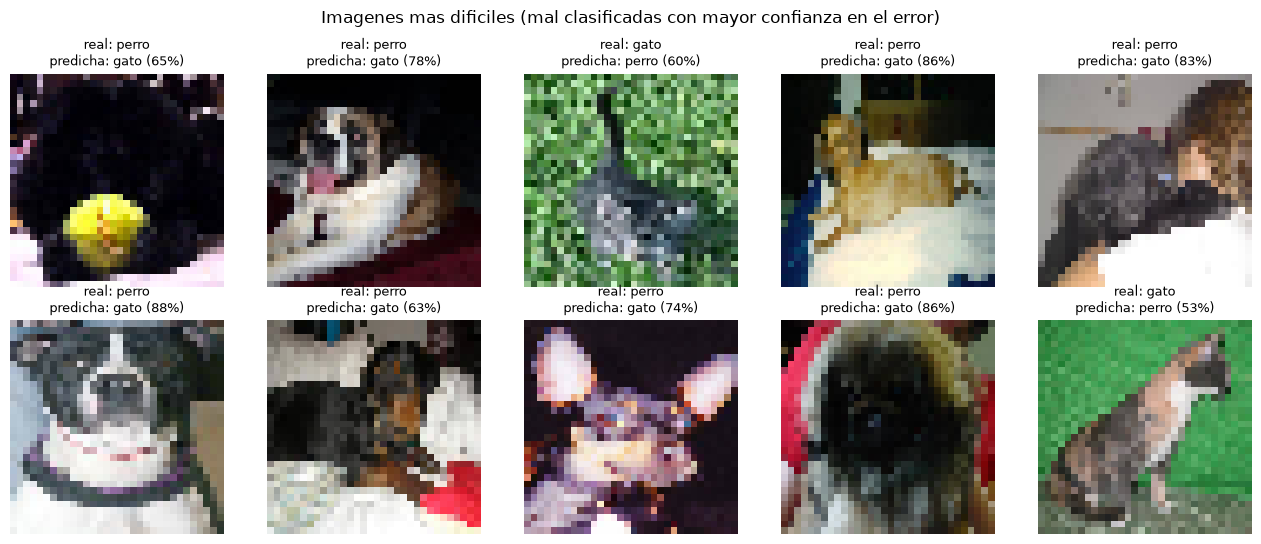

In [13]:
n_mostrar = min(10, len(imagenes_dificiles_idx))
fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))

for ax, idx in zip(axes.flatten(), imagenes_dificiles_idx[:n_mostrar]):
    ax.imshow(X_test[idx])
    real = clases[y_test[idx]]
    predicha = clases[y_pred[idx]]
    confianza = confianza_error[np.where(orden == idx)[0][0]]
    ax.set_title(f"real: {real}\npredicha: {predicha} ({confianza:.0%})", fontsize=9)
    ax.axis("off")

plt.suptitle("Imagenes mas dificiles (mal clasificadas con mayor confianza en el error)")
plt.tight_layout()
plt.show()


Estas son las imágenes que un sistema "anti-CAPTCHA" como el que hemos simulado peor clasifica, así que serían las mejores candidatas para usar en el CAPTCHA de la empresa: son las más difíciles para una máquina, aunque para nosotros siga siendo fácil ver si es un perro o un gato.